# Data Overview

## Load Olist Tables
Olist database contains 11 tables, but by simplicity, only `orders`, `order_items`, `products`, `customers`, `product_category_name_translation` were selected.

In [1]:
import pandas as pd
from pathlib import Path
from omegaconf import OmegaConf
from olist_ml.config import OlistConfig
from sqlalchemy import create_engine
root_path = project_root=Path.cwd().parent
cfg = OmegaConf.load("../conf/config.yaml")

raw_data_path = root_path / cfg.paths.raw_data
olist_sqlite_path = raw_data_path / cfg.files.olist_sqlite
db_file = f"sqlite:///{olist_sqlite_path}"
engine = create_engine(db_file)

In [2]:
orders_df = pd.read_sql("SELECT * FROM orders;", engine)
order_items_df = pd.read_sql("SELECT * FROM order_items;", engine)
products_df = pd.read_sql("SELECT * FROM products;", engine)
customers_df = pd.read_sql("SELECT * FROM customers;", engine)
product_category_name_translation_df = pd.read_sql("SELECT * FROM product_category_name_translation;", engine)

## Tables Overview

### Orders

In [3]:
print(orders_df.shape)
print(orders_df.columns)

(99441, 8)
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')


There are 99441 rows and 8 columns, the columns are about identifiers of the order, its customer, order status and date-related columns about order purchase, order delivery, etc.

In [4]:
print(orders_df.head().T)

                                                              0  \
order_id                       e481f51cbdc54678b7cc49136f2d6af7   
customer_id                    9ef432eb6251297304e76186b10a928d   
order_status                                          delivered   
order_purchase_timestamp                    2017-10-02 10:56:33   
order_approved_at                           2017-10-02 11:07:15   
order_delivered_carrier_date                2017-10-04 19:55:00   
order_delivered_customer_date               2017-10-10 21:25:13   
order_estimated_delivery_date               2017-10-18 00:00:00   

                                                              1  \
order_id                       53cdb2fc8bc7dce0b6741e2150273451   
customer_id                    b0830fb4747a6c6d20dea0b8c802d7ef   
order_status                                          delivered   
order_purchase_timestamp                    2018-07-24 20:41:37   
order_approved_at                           2018-07-26 03:24:

This show us 5 `delivered` orders between 2017 and 2018, there are 5 date-related columns and 2 identifiers of the order and the customer.
On its own, this information provides limited insight, so in the future it'll be necesarry to combine it with another tables in later stages of the analysis.

In [5]:
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


All of the column `dtypes`  are object, which it's not always ideal, because there are dates, status for example. So it's somethig to change.

=== DESCRIBE ===
       order_status
count         99441
unique            8
top       delivered
freq          96478

=== VALUE COUNTS ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


<Axes: title={'center': 'Number of Orders by Order Status'}, xlabel='Order Status', ylabel='Number of Orders'>

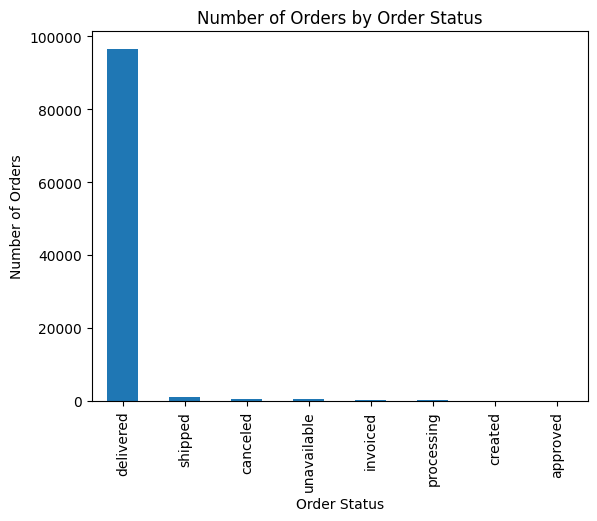

In [6]:
print("=== DESCRIBE ===")
print(orders_df[['order_status']].describe())
print("\n=== VALUE COUNTS ===")
print(orders_df['order_status'].value_counts())
orders_df['order_status'].value_counts().plot(kind="bar", xlabel="Order Status", ylabel="Number of Orders", title="Number of Orders by Order Status")

In the `describe` output `order_status` has 8 unique values, the most common is `delivered` which has a frequency of 96478, so the majority of the orders have the `delivered` status.

In [7]:
print(orders_df.isna().sum())
print(orders_df.isna().sum()/len(orders_df))

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.001609
order_delivered_carrier_date     0.017930
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
dtype: float64


`order_approved_at` has only 160 missing values, which is negligible.
`order_delivered_carrier_date` has 1783 missing values, and `order_delivered_customer_date` has 2965 missing values, representing approximately 1% and 3% of the data, respectively.

### Order Items

In [8]:
print(order_items_df.shape)
print(order_items_df.columns)

(112650, 7)
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')


There are 112650 rows and 7 columns, identifiers about order, order item, product, seller, shipping deadline, prices, etc.

In [9]:
print(order_items_df.head().T)

                                                    0  \
order_id             00010242fe8c5a6d1ba2dd792cb16214   
order_item_id                                       1   
product_id           4244733e06e7ecb4970a6e2683c13e61   
seller_id            48436dade18ac8b2bce089ec2a041202   
shipping_limit_date               2017-09-19 09:45:35   
price                                            58.9   
freight_value                                   13.29   

                                                    1  \
order_id             00018f77f2f0320c557190d7a144bdd3   
order_item_id                                       1   
product_id           e5f2d52b802189ee658865ca93d83a8f   
seller_id            dd7ddc04e1b6c2c614352b383efe2d36   
shipping_limit_date               2017-05-03 11:05:13   
price                                           239.9   
freight_value                                   19.93   

                                                    2  \
order_id             000229ec

This output confirm that there are some identifiers, but `order_item_id` is different, looking for more information on the kaggle dataset documentation it represent a sequential number identifying number of items included in the same order, so it's not a identifier at all.
There are present `shipping_limit_date` between 2017 and 2018.
And Finally prices about every item and a `freight_value`.
According to the kaggle dataset documentation, there is a instruction to follow to calculate the total order amount:

> **How to calculate total order amount:**
The order_id = 00143d0f86d6fbd9f9b38ab440ac16f5 has 3 items (same product). Each item has the freight calculated accordingly to its measures and weight. To get the total freight value for each order you just have to sum.
Total order_item value: 21.33 \* 3 = 63.99
Total freight value: 15.10 \* 3 = 45.30
Total order value: 45.30 + 63.99 = 109.29

The Kaggle dataset documentation does not explicitly mention the currency used for monetary values; however, it is inferred that prices are expressed in Brazilian Reais (BRL).

In [10]:
print(order_items_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None


Similiar to the orders table, date-related columns such as `shipping_limit_date` should be converted to a proper datetime `dtype`.
The output confirm that `order_item_id` is a positional identifier within each order.
`price` and `freight_value` are stored as floating-point values, which is appropiate for monetary data.

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


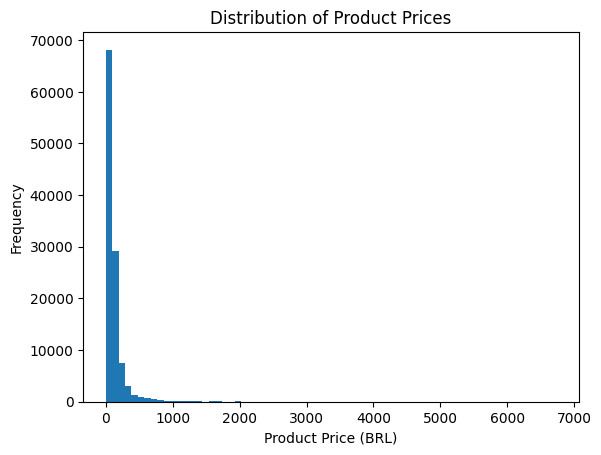

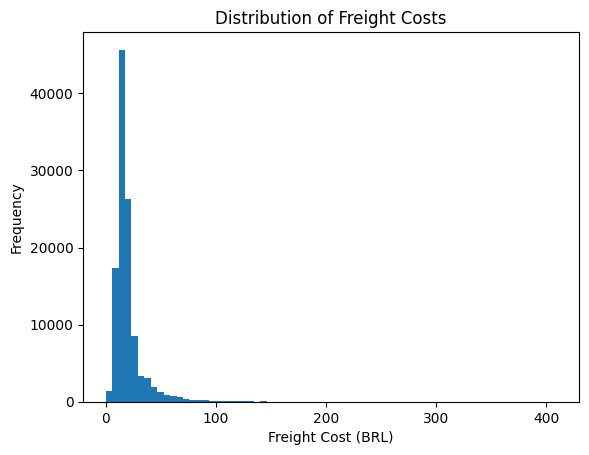

In [11]:
import matplotlib.pyplot as plt
print(order_items_df[['price', 'freight_value']].describe())
order_items_df['price'].plot(kind="hist", bins=70, xlabel="Product Price (BRL)", ylabel="Frequency", title="Distribution of Product Prices")
plt.show();
order_items_df['freight_value'].plot(kind="hist", bins=70, xlabel="Freight Cost (BRL)", ylabel="Frequency", title="Distribution of Freight Costs")
plt.show();

Prices range from 0.85 BRL to 6735 BRL, with a mean value of 120.65 BRL. High-priced products are relatively uncommon, as 75% of the items cost 134.90 BRL or less.

Regarding shipping costs, the `freight_value` ranges from 0 BRL to 409.68 BRL. In most cases, shipping costs are relatively low, with 75% of the values below the upper quartile, and some exceptional cases where shipping is free.

order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64


<Axes: title={'center': 'Distribution of Order Items per Order'}, xlabel='Number of Order Items', ylabel='Frequency'>

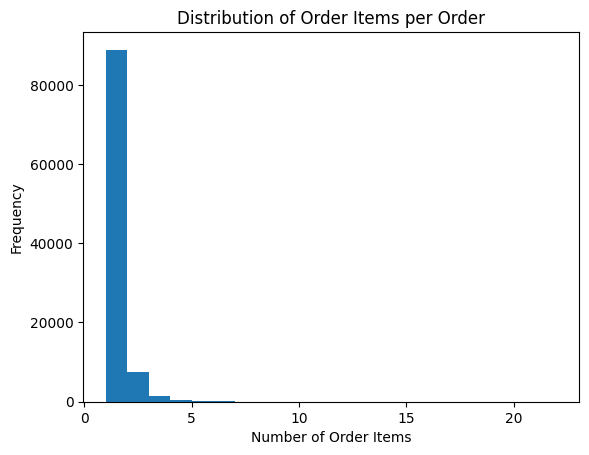

In [12]:
print(
    order_items_df
    .groupby("order_id")["order_item_id"]
    .max()
    .value_counts()
    .sort_index()
)
order_counts = order_items_df.groupby("order_id")["order_item_id"].max()

order_items_df \
    .groupby("order_id")["order_item_id"] \
    .max().plot(kind="hist", bins=range(1, order_counts.max()+2), xlabel="Number of Order Items", ylabel="Frequency", title="Distribution of Order Items per Order")

The distribution shows that most orders contain only 1 order item, while orders with 7 to 21 order items are very uncommon.

In [13]:
print(order_items_df.isna().sum())

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


There are no missing values in the order items table.

### Products

In [14]:
print(products_df.shape)
print(products_df.columns)

(32951, 9)
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


There are 32,951 rows and 9 columns. Each product is associated with a category name (in Portuguese) and includes limited information such as product name and description length, as well as physical attributes like weight, height, length, and width.

In [15]:
print(products_df.head().T)

                                                           0  \
product_id                  1e9e8ef04dbcff4541ed26657ea517e5   
product_category_name                             perfumaria   
product_name_lenght                                     40.0   
product_description_lenght                             287.0   
product_photos_qty                                       1.0   
product_weight_g                                       225.0   
product_length_cm                                       16.0   
product_height_cm                                       10.0   
product_width_cm                                        14.0   

                                                           1  \
product_id                  3aa071139cb16b67ca9e5dea641aaa2f   
product_category_name                                  artes   
product_name_lenght                                     44.0   
product_description_lenght                             276.0   
product_photos_qty                     

Since it is not possible to retrieve the actual product names, products will be referred to by their identifiers (`product_id`) throughout the analysis.
Some variables, such as `product_category_name`, `product_name_length`, `product_description_length`, and `product_photos_qty`, are related to the product detail page, while the product dimensions are more relevant to delivery and shipping costs.

In [16]:
print(products_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None


`product_category_name` is stored as a object, but a categorical `dtype` would be more appropiate than just a object.

In [17]:
print(products_df['product_category_name'].describe())

count               32341
unique                 73
top       cama_mesa_banho
freq                 3029
Name: product_category_name, dtype: object


There are 73 unique categories. The category with the most products is `cama_mesa_banho`, with 3029 products.

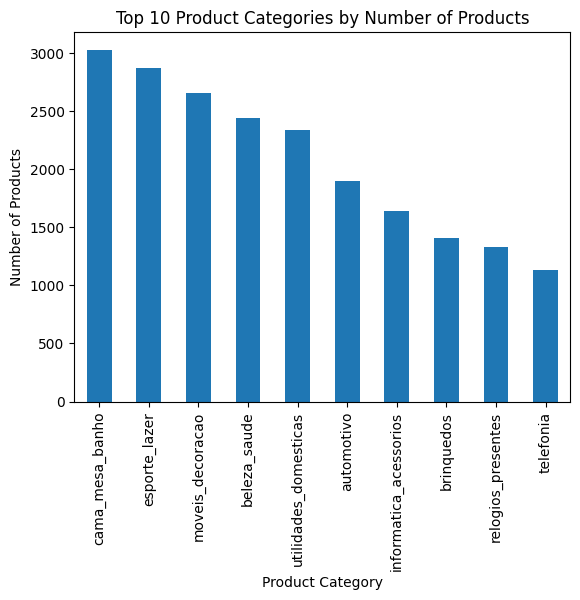

Top 10 categories total percentaje: 62.96%


In [18]:
import matplotlib.pyplot as plt
products_df['product_category_name'].value_counts().head(10).plot(kind="bar", xlabel="Product Category", ylabel="Number of Products", title= "Top 10 Product Categories by Number of Products")
plt.show()
print(f"Top 10 categories total percentaje: {products_df['product_category_name'].value_counts().head(10).sum()/len(products_df['product_category_name'])*100:0.2f}%")

Categories with the most products include `cama_mesa_banho`, `esporte_lazer`, `moveis_decoracao`, `beleza_saude`, `utilidades_domesticas`, `automotivo`, `informatica_accessorios`, `brinquedos`, `relogios_presentes`, and `telefonia`, accounting for 62.96% of all products.

In [19]:
print(products_df.isna().sum())
print(products_df.isna().sum()/len(products_df))

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
product_id                    0.000000
product_category_name         0.018512
product_name_lenght           0.018512
product_description_lenght    0.018512
product_photos_qty            0.018512
product_weight_g              0.000061
product_length_cm             0.000061
product_height_cm             0.000061
product_width_cm              0.000061
dtype: float64


There are 610 missing values in `product_category_name`, which represent 1.8% of the total products. Therefore, these products can be safely discarded, as they do not have an associated category.

### Customers

In [20]:
print(customers_df.shape)
print(customers_df.columns)

(99441, 5)
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')


There are 99441 rows and 5 columns in the customers table, the number of rows matches the number of orders because Olist assigns a new `customer_id` for each order, even when the same customer makes multiple purchases.
To identify unique customers, we must rely on the `customer_unique_id`, which represents the real customer across multiple orders.
Geographic attributes such as `customer_zip_code_prefix`, `customer_city`, and `customer_state` are associated with the order-level customer record and can be used for regional analysis.

In [21]:
print(customers_df.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


Brazil is divided into multiple states, making `customer_state` a high-level geographic division.
Within each state, `customer_city` represents a municipality, which is a lower-level administrative subdivision of the state. View [list of cities and towns in Brazil](https://www.britannica.com/topic/list-of-cities-and-towns-in-Brazil-2055400) to see more information.
The `customer_zip_code_prefix` feature does not provide additional information beyond what is already captured by `customer_state` and `customer_city`, therefore it was discarded from the analysis.

In [22]:
print(customers_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None


The `customer_city` and `customer_state` are stored as object `dtype`, it  is appropriate to convert them to a categorical `dtype`.

count                                99441
unique                               96096
top       8d50f5eadf50201ccdcedfb9e2ac8455
freq                                    17
Name: customer_unique_id, dtype: object


<Axes: title={'center': 'Distribution of Orders per Customer'}, xlabel='Number of Orders', ylabel='Number of Customers'>

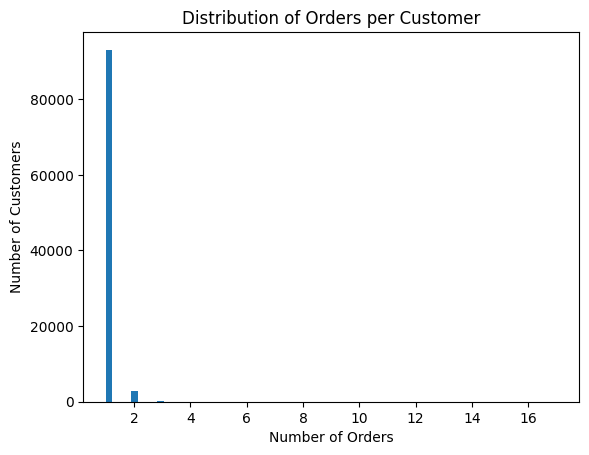

In [23]:
print(customers_df['customer_unique_id'].describe())
customers_df['customer_unique_id'].value_counts().plot(
    kind="hist",
    bins=70,
    xlabel="Number of Orders",
    ylabel="Number of Customers",
    title="Distribution of Orders per Customer"
)

There are 96096 unique customers identified by `customer_unique_id`, One customer `customer_unique_id=8d50f5eadf50201ccdcedfb9e2ac8455` stands out as an extreme case, having placed 17 orders, which is the maximum. The majority of unique customers placed 1 order.

       customer_city customer_state
count          99441          99441
unique          4119             27
top        sao paulo             SP
freq           15540          41746


<Axes: title={'center': 'Top 10 (city, state) vs Number of Orders'}, xlabel='City and State', ylabel='Number of Orders'>

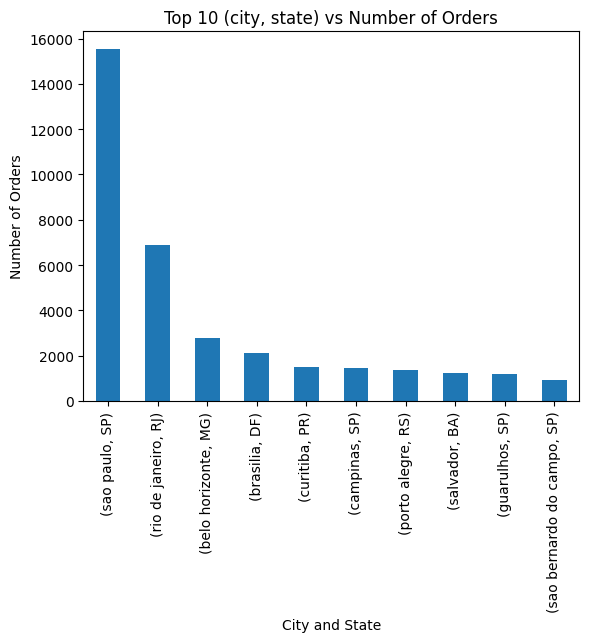

In [24]:
print(customers_df[['customer_city', 'customer_state']].describe())
customers_df.value_counts(['customer_city', 'customer_state']).head(10).plot(kind="bar", xlabel="City and State", ylabel="Number of Orders", title="Top 10 (city, state) vs Number of Orders")

The city with the highest number of orders is Sao Paulo,with 15540 orders. At the state level, Sao Paulo (SP) is the state with the largest number of orders, totaling 41.746 orders.

In [25]:
print(customers_df.isna().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


There are no missing values in the customers table.

### Product Category Name Translation

In [26]:
product_category_name_translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


This table is useful for obtaining English names for product categories, helping to avoid misunderstandings caused by translation.

It contains 71 translated product categories. However, the products table includes 73 distinct categories, meaning that 2 categories do not have a corresponding English translation.

In [27]:
missing_categories = (
    products_df
    .loc[
        ~products_df["product_category_name"].isin(
            product_category_name_translation_df["product_category_name"]
        ),
        "product_category_name"
    ]
    .unique()
)
missing_categories

array([None, 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
      dtype=object)

To avoid this issue, it is possible to add two rows to the translation table providing translations for:
`pc_gamer` → `pc_gamer`
`portateis_cozinha_e_preparadores_de_alimentos` → `portable_kitchen_and_food_preparation_appliances`